# 🏭 Pipeline ML — Prévision CA Mensuel (12 mois)
**Architecture** : ClickHouse Gold → Feature Engineering → LightGBM + Prophet → Ensemble → MLflow

| Paramètre | Valeur |
|-----------|--------|
| Source | `gold.fact_sales` + 5 dimensions |
| Cible | CA mensuel agrégé |
| Horizon | 12 mois |
| Modèles | LightGBM · Prophet · Ensemble pondéré |
| Tracking | MLflow (`http://mlflow:5000`) |
| Résultats | `gold.ml_predictions` |


In [1]:
# ── Installation des dépendances dans le container ──
import sys
!{sys.executable} -m pip install -q clickhouse-connect prophet lightgbm scikit-learn matplotlib pandas numpy

print("✅ Toutes les dépendances sont installées")



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
✅ Toutes les dépendances sont installées


## 0. Imports & Configuration

In [2]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from datetime import datetime

# ClickHouse
import clickhouse_connect

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

# Modèles
import lightgbm as lgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

print("✅ Tous les imports OK")


✅ Tous les imports OK


## 1. Connexion ClickHouse

In [3]:
import clickhouse_connect
import os

CH_HOST     = os.getenv("CLICKHOUSE_HOST",     "clickhouse")
CH_PORT     = int(os.getenv("CLICKHOUSE_PORT", "8123"))
CH_USER     = os.getenv("CLICKHOUSE_USER",     "default")
CH_PASSWORD = os.getenv("CLICKHOUSE_PASSWORD", "clickhouse123")
CH_DB       = os.getenv("CLICKHOUSE_DB",       "gold")

client = clickhouse_connect.get_client(
    host=CH_HOST,
    port=CH_PORT,
    user=CH_USER,
    password=CH_PASSWORD,
    database=CH_DB,
)
print(f"✅ Connecté à ClickHouse : {CH_HOST}:{CH_PORT}/{CH_DB}")


✅ Connecté à ClickHouse : clickhouse:8123/gold


## 2. Extraction — Requête avec toutes les jointures
Filtres métier :
- **Types acceptés** : `DocumentTypeSK IN (1, 4, 6)`
- **Statuts exclus** : `DocumentStatusSK NOT IN (4, 13)`


In [4]:
QUERY = """
SELECT
    toDate(toString(fs.DateSK), '%Y%m%d')          AS sale_date,
    dc.ClientCode                                   AS ClientCode,
    dc.IsBTOB                                       AS IsBTOB,
    di.ItemCode                                     AS ItemCode,
    di.Brand                                        AS Brand,
    di.Family                                       AS Family,
    dg.GeographicalAreaLabel                        AS region,
    dw.WarehouseName                                AS warehouse,
    ddt.DocumentTypeLabel                           AS doc_type,
    dds.DocumentStatusLabel                         AS doc_status,
    fs.Quantity                                     AS Quantity,
    fs.LinePrice                                    AS LinePrice,
    fs.CostPrice                                    AS CostPrice,
    fs.DiscountAmount                               AS DiscountAmount,
    fs.DiscountPercentage                           AS DiscountPercentage,
    fs.LinePrice                                    AS ca_ligne

FROM gold.fact_sales fs
JOIN gold.dim_client            dc  ON fs.ClientSK          = dc.ClientSK
JOIN gold.dim_item               di  ON fs.ItemSK             = di.ItemSK
JOIN gold.dim_geographical_area  dg  ON fs.GeographicalAreaSK = dg.GeographicalAreaSK
JOIN gold.dim_warehouse          dw  ON fs.WarehouseSK        = dw.WarehouseSK
JOIN gold.dim_document_type      ddt ON fs.DocumentTypeSK     = ddt.DocumentTypeSK
JOIN gold.dim_document_status    dds ON fs.DocumentStatusSK   = dds.DocumentStatusSK

WHERE fs.DocumentTypeSK   IN (1, 4, 6)
  AND fs.DocumentStatusSK NOT IN (4, 13)
  AND fs.LinePrice IS NOT NULL
  AND fs.LinePrice > 0
  AND fs.DateSK IS NOT NULL
"""

print("⏳ Chargement des données depuis ClickHouse...")
result = client.query(QUERY)
df_raw = pd.DataFrame(result.result_rows, columns=result.column_names)
df_raw["sale_date"] = pd.to_datetime(df_raw["sale_date"])
df_raw["month_period"] = df_raw["sale_date"].dt.to_period("M")

print(f"✅ {len(df_raw):,} lignes chargées")
print(f"   Période : {df_raw['sale_date'].min().date()} → {df_raw['sale_date'].max().date()}")
print(f"   Colonnes : {df_raw.columns.tolist()}")
df_raw.head(3)


⏳ Chargement des données depuis ClickHouse...
✅ 627,576 lignes chargées
   Période : 2021-03-01 → 2026-02-14
   Colonnes : ['sale_date', 'ClientCode', 'IsBTOB', 'ItemCode', 'Brand', 'Family', 'region', 'warehouse', 'doc_type', 'doc_status', 'Quantity', 'LinePrice', 'CostPrice', 'DiscountAmount', 'DiscountPercentage', 'ca_ligne', 'month_period']


,sale_date,ClientCode,IsBTOB,ItemCode,Brand,Family,region,warehouse,doc_type,doc_status,Quantity,LinePrice,CostPrice,DiscountAmount,DiscountPercentage,ca_ligne,month_period
0,2024-01-19,C-41100341,0,880003A,ERA,Allumage / préchauffage,"SFAX 1 ""STE""",Detail,BC,Balanced,1,135.120,93.186,0.0,0.0,135.120,2024-01
1,2024-01-19,C-41100341,0,IB-15600,PHIRA,Carrosserie,"SFAX 1 ""STE""",Central,BC,Balanced,1,75.767,65.884,0.0,0.0,75.767,2024-01
2,2024-01-19,C-41100341,0,SEA15IB005,DE-GA,Carrosserie,"SFAX 1 ""STE""",Rte Gabes,BC,Balanced,1,32.156,25.725,0.0,0.0,32.156,2024-01


## 3. Agrégation Mensuelle

In [5]:
df_raw["month_period"] = df_raw["sale_date"].dt.to_period("M")

df_monthly = (
    df_raw
    .groupby("month_period")
    .agg(
        ca_total        = ("ca_ligne",           "sum"),
        nb_transactions = ("ca_ligne",           "count"),
        nb_clients      = ("ClientCode",         "nunique"),
        nb_produits     = ("ItemCode",           "nunique"),
        qty_total       = ("Quantity",           "sum"),
        discount_moy    = ("DiscountPercentage", "mean"),
    )
    .reset_index()
)
df_monthly["ds"] = df_monthly["month_period"].dt.to_timestamp()
df_monthly = df_monthly.sort_values("ds").reset_index(drop=True)

print(f"✅ {len(df_monthly)} mois disponibles")
df_monthly[["ds","ca_total","nb_transactions","nb_clients"]].tail(8)


✅ 51 mois disponibles


,ds,ca_total,nb_transactions,nb_clients
43,2025-07-01,2191687.719,19605,318
44,2025-08-01,1870167.970,16783,313
45,2025-09-01,2082950.341,17737,322
46,2025-10-01,2142087.336,19236,320
47,2025-11-01,1863621.819,17397,318
48,2025-12-01,2063128.797,19945,337
49,2026-01-01,1703449.415,17098,308
50,2026-02-01,336017.620,3387,129


### 3.1 Visualisation de l'historique

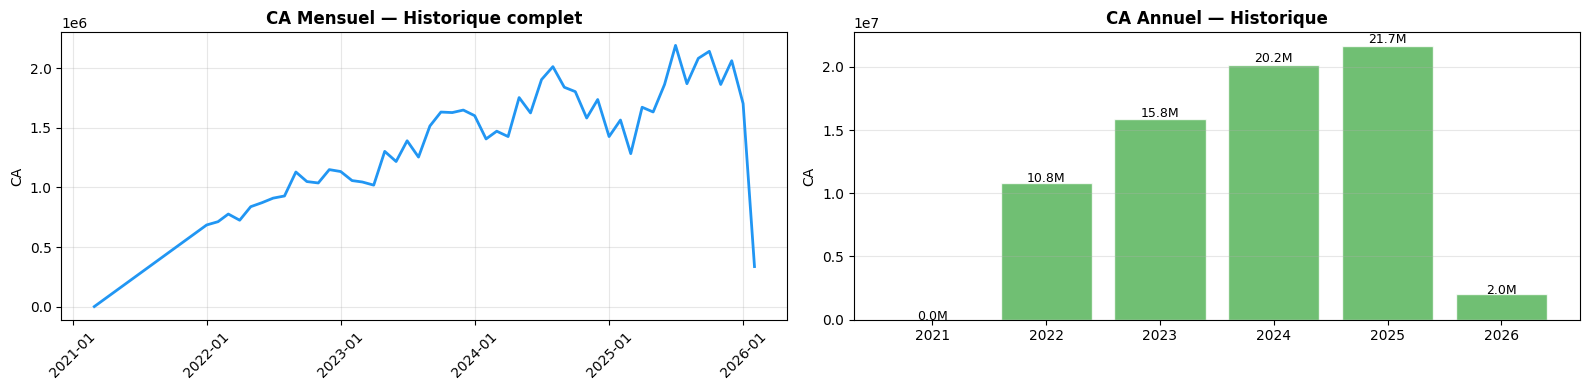

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df_monthly["ds"], df_monthly["ca_total"], color="#2196F3", lw=2)
axes[0].set_title("CA Mensuel — Historique complet", fontweight="bold")
axes[0].set_ylabel("CA"); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].tick_params(axis="x", rotation=45)

df_raw["year_num"] = df_raw["sale_date"].dt.year
ca_annual = df_raw.groupby("year_num")["ca_ligne"].sum()
axes[1].bar(ca_annual.index, ca_annual.values, color="#4CAF50", alpha=0.8, edgecolor="white")
axes[1].set_title("CA Annuel — Historique", fontweight="bold")
axes[1].set_ylabel("CA"); axes[1].grid(alpha=0.3, axis="y")
for x, y in zip(ca_annual.index, ca_annual.values):
    axes[1].text(x, y * 1.01, f"{y/1e6:.1f}M", ha="center", fontsize=9)

plt.tight_layout(); plt.show()


## 4. Feature Engineering
- **Calendaires** : année, mois, trimestre encodés cycliquement (sin/cos)
- **Lags** : CA à 1, 2, 3, 6, 12 mois
- **Rolling** : moyennes et écarts-types glissants (3, 6, 12 mois)
- **Croissance** : MoM, QoQ, YoY
- **Métier** : nb clients, panier moyen, discount moyen


In [7]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["year"]        = df["ds"].dt.year
    df["month"]       = df["ds"].dt.month
    df["quarter"]     = df["ds"].dt.quarter
    df["month_sin"]   = np.sin(2 * np.pi * df["month"]   / 12)
    df["month_cos"]   = np.cos(2 * np.pi * df["month"]   / 12)
    df["quarter_sin"] = np.sin(2 * np.pi * df["quarter"] / 4)
    df["quarter_cos"] = np.cos(2 * np.pi * df["quarter"] / 4)
    df["trend"]       = np.arange(len(df))

    for lag in [1, 2, 3, 6, 12]:
        df[f"ca_lag_{lag}"] = df["ca_total"].shift(lag)

    for w in [3, 6, 12]:
        df[f"ca_roll_mean_{w}"] = df["ca_total"].shift(1).rolling(w).mean()
        df[f"ca_roll_std_{w}"]  = df["ca_total"].shift(1).rolling(w).std()

    df["ca_growth_1m"]  = df["ca_total"].pct_change(1)
    df["ca_growth_3m"]  = df["ca_total"].pct_change(3)
    df["ca_growth_12m"] = df["ca_total"].pct_change(12)
    df["panier_moyen"]  = df["ca_total"] / df["nb_transactions"].replace(0, np.nan)
    df["discount_moy"]  = df["discount_moy"].fillna(0)
    return df

FEATURE_COLS = [
    "year", "month", "quarter",
    "month_sin", "month_cos", "quarter_sin", "quarter_cos", "trend",
    "ca_lag_1", "ca_lag_2", "ca_lag_3", "ca_lag_6", "ca_lag_12",
    "ca_roll_mean_3", "ca_roll_mean_6", "ca_roll_mean_12",
    "ca_roll_std_3",  "ca_roll_std_6",  "ca_roll_std_12",
    "ca_growth_1m", "ca_growth_3m", "ca_growth_12m",
    "nb_transactions", "nb_clients", "discount_moy", "panier_moyen",
]
TARGET = "ca_total"

df_feat = build_features(df_monthly).dropna()
print(f"✅ {df_feat.shape[1]} colonnes · {len(df_feat)} mois utilisables après suppression NaN")
df_feat[["ds","ca_total","ca_lag_1","ca_roll_mean_3","ca_growth_12m"]].tail(5)


✅ 31 colonnes · 39 mois utilisables après suppression NaN


,ds,ca_total,ca_lag_1,ca_roll_mean_3,ca_growth_12m
46,2025-10-01,2142087.336,2082950.341,2.048269e+06,0.187590
47,2025-11-01,1863621.819,2142087.336,2.031735e+06,0.177836
48,2025-12-01,2063128.797,1863621.819,2.029553e+06,0.187348
49,2026-01-01,1703449.415,2063128.797,2.022946e+06,0.193927
50,2026-02-01,336017.620,1703449.415,1.876733e+06,-0.785345


## 5. Split Train / Test (6 derniers mois = test)

In [8]:
TEST_SIZE = 6

train = df_feat.iloc[:-TEST_SIZE]
test  = df_feat.iloc[-TEST_SIZE:]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f"Train : {train['ds'].min().strftime('%Y-%m')} → {train['ds'].max().strftime('%Y-%m')}  ({len(train)} mois)")
print(f"Test  : {test['ds'].min().strftime('%Y-%m')}  → {test['ds'].max().strftime('%Y-%m')}   ({len(test)} mois)")


Train : 2022-12 → 2025-08  (33 mois)
Test  : 2025-09  → 2026-02   (6 mois)


## 6. MLflow Setup

In [9]:
MLFLOW_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("prevision_ca_mensuel")
print(f"✅ MLflow : {MLFLOW_URI}  |  Experiment : prevision_ca_mensuel")


2026/05/15 10:21:05 INFO mlflow.tracking.fluent: Experiment with name 'prevision_ca_mensuel' does not exist. Creating a new experiment.


✅ MLflow : http://mlflow:5000  |  Experiment : prevision_ca_mensuel


## 7A. Modèle 1 — LightGBM
Cross-validation temporelle (3 folds) + early stopping + régularisation L1/L2.


In [10]:
lgb_params = {
    "objective":         "regression",
    "metric":            "mape",
    "boosting_type":     "gbdt",
    "n_estimators":      500,
    "learning_rate":     0.03,
    "num_leaves":        31,
    "max_depth":         6,
    "min_child_samples": 5,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "reg_alpha":         0.1,
    "reg_lambda":        0.1,
    "random_state":      42,
    "verbose":           -1,
}

with mlflow.start_run(run_name="LightGBM_CA_Mensuel"):
    model_lgb = lgb.LGBMRegressor(**lgb_params)

    tscv = TimeSeriesSplit(n_splits=3)
    cv_mapes = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        mape_fold = mean_absolute_percentage_error(y_val, model_lgb.predict(X_val))
        cv_mapes.append(mape_fold)
        print(f"  Fold {fold+1} MAPE : {mape_fold:.2%}")

    model_lgb.fit(X_train, y_train, eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

    pred_lgb_test = model_lgb.predict(X_test)
    mape_lgb      = mean_absolute_percentage_error(y_test, pred_lgb_test)
    rmse_lgb      = np.sqrt(mean_squared_error(y_test, pred_lgb_test))
    cv_mape_mean  = np.mean(cv_mapes)

    mlflow.log_params(lgb_params)
    mlflow.log_metrics({"test_mape": mape_lgb, "test_rmse": rmse_lgb, "cv_mape": cv_mape_mean})
    mlflow.lightgbm.log_model(model_lgb, "lightgbm_model")

print(f"\n✅ CV MAPE moyen : {cv_mape_mean:.2%}")
print(f"✅ Test MAPE     : {mape_lgb:.2%}")
print(f"✅ Test RMSE     : {rmse_lgb:,.0f}")


2026/05/15 10:21:05 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



  Fold 1 MAPE : 23.53%
  Fold 2 MAPE : 10.71%
  Fold 3 MAPE : 10.60%

✅ CV MAPE moyen : 14.95%
✅ Test MAPE     : 50.39%
✅ Test RMSE     : 406,920


## 7B. Modèle 2 — Prophet
Saisonnalité **multiplicative** + saisonnalité trimestrielle personnalisée. Intervalle de confiance 80%.


In [11]:
df_prophet_train = df_monthly.iloc[:-TEST_SIZE][["ds","ca_total"]].rename(columns={"ca_total":"y"})
df_prophet_test  = df_monthly.iloc[-TEST_SIZE:][["ds","ca_total"]].rename(columns={"ca_total":"y"})

with mlflow.start_run(run_name="Prophet_CA_Mensuel"):
    model_prophet = Prophet(
        seasonality_mode        = "multiplicative",
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 10.0,
        interval_width          = 0.80,
    )
    model_prophet.add_seasonality(name="quarterly", period=91.25, fourier_order=5)
    model_prophet.fit(df_prophet_train)

    future_test       = model_prophet.make_future_dataframe(periods=TEST_SIZE, freq="MS")
    forecast_test_df  = model_prophet.predict(future_test)
    pred_prophet_test = forecast_test_df.tail(TEST_SIZE)["yhat"].values.clip(min=0)

    mape_prophet = mean_absolute_percentage_error(df_prophet_test["y"], pred_prophet_test)
    rmse_prophet = np.sqrt(mean_squared_error(df_prophet_test["y"], pred_prophet_test))

    mlflow.log_metrics({"test_mape": mape_prophet, "test_rmse": rmse_prophet})

print(f"✅ Test MAPE : {mape_prophet:.2%}")
print(f"✅ Test RMSE : {rmse_prophet:,.0f}")


10:21:17 - cmdstanpy - INFO - Chain [1] start processing
10:21:17 - cmdstanpy - INFO - Chain [1] done processing


✅ Test MAPE : 69.29%
✅ Test RMSE : 553,291


## 7C. Modèle 3 — Ensemble pondéré
Pondération **inversement proportionnelle à la MAPE** : le meilleur modèle contribue davantage.


In [12]:
w_lgb     = 1 / mape_lgb
w_prophet = 1 / mape_prophet
w_total   = w_lgb + w_prophet

pred_ensemble_test = (w_lgb * pred_lgb_test + w_prophet * pred_prophet_test) / w_total

mape_ensemble = mean_absolute_percentage_error(y_test, pred_ensemble_test)
rmse_ensemble = np.sqrt(mean_squared_error(y_test, pred_ensemble_test))

print(f"Poids LightGBM : {w_lgb/w_total:.1%}  |  Poids Prophet : {w_prophet/w_total:.1%}")
print(f"✅ Ensemble MAPE : {mape_ensemble:.2%}")
print(f"✅ Ensemble RMSE : {rmse_ensemble:,.0f}")


Poids LightGBM : 57.9%  |  Poids Prophet : 42.1%
✅ Ensemble MAPE : 58.21%
✅ Ensemble RMSE : 456,404


## 8. Prévision 12 mois à venir
- **Prophet** : forecast direct avec intervalles de confiance
- **LightGBM** : forecast **rolling** (chaque prédiction réinjectée comme lag)
- **Ensemble** : combinaison pondérée finale


In [13]:
HORIZON = 12

# ── Prophet ──
future_12        = model_prophet.make_future_dataframe(periods=HORIZON + TEST_SIZE, freq="MS")
forecast_12_full = model_prophet.predict(future_12)
forecast_12_p    = forecast_12_full.tail(HORIZON)[["ds","yhat","yhat_lower","yhat_upper"]].copy()
for col in ["yhat","yhat_lower","yhat_upper"]:
    forecast_12_p[col] = forecast_12_p[col].clip(lower=0)

# ── LightGBM rolling ──
df_extended = df_monthly.copy()
future_lgb_preds = []

for i in range(HORIZON):
    next_ds = df_extended["ds"].max() + pd.DateOffset(months=1)
    new_row = pd.DataFrame([{
        "ds":              next_ds,
        "month_period":    pd.Period(next_ds, "M"),
        "ca_total":        np.nan,
        "nb_transactions": df_extended["nb_transactions"].tail(6).mean(),
        "nb_clients":      df_extended["nb_clients"].tail(6).mean(),
        "qty_total":       df_extended["qty_total"].tail(6).mean(),
        "discount_moy":    df_extended["discount_moy"].tail(6).mean(),
    }])
    df_extended = pd.concat([df_extended, new_row], ignore_index=True)
    feat_row = build_features(df_extended).iloc[[-1]][FEATURE_COLS]
    pred_val = max(model_lgb.predict(feat_row)[0], 0)
    df_extended.loc[df_extended.index[-1], "ca_total"] = pred_val
    future_lgb_preds.append(pred_val)

# ── Ensemble ──
forecast_final = forecast_12_p.copy()
forecast_final["yhat_lgb"]      = future_lgb_preds
forecast_final["yhat_ensemble"] = (
    (w_lgb * forecast_final["yhat_lgb"] + w_prophet * forecast_final["yhat"]) / w_total
)

ca_annuel_prevu = forecast_final["yhat_ensemble"].sum()
ca_annuel_hist  = df_monthly["ca_total"].tail(12).sum()
delta_pct       = (ca_annuel_prevu - ca_annuel_hist) / ca_annuel_hist

print(f"💰 CA prévu 12 mois    : {ca_annuel_prevu:>15,.0f}")
print(f"📈 CA réel 12m hist.   : {ca_annuel_hist:>15,.0f}")
print(f"📊 Évolution prévue    : {delta_pct:>+14.1%}")


💰 CA prévu 12 mois    :      21,188,059
📈 CA réel 12m hist.   :      20,705,736
📊 Évolution prévue    :          +2.3%


In [14]:
# Tableau propre
display_df = forecast_final[["ds","yhat_lgb","yhat","yhat_ensemble","yhat_lower","yhat_upper"]].copy()
display_df.columns = ["Mois","LightGBM","Prophet","Ensemble","IC Bas 80%","IC Haut 80%"]
display_df["Mois"] = display_df["Mois"].dt.strftime("%Y-%m")
for col in display_df.columns[1:]:
    display_df[col] = display_df[col].map("{:,.0f}".format)
display_df


,Mois,LightGBM,Prophet,Ensemble,IC Bas 80%,IC Haut 80%
51,2026-03,"1,587,989","1,457,687","1,533,125","1,386,072","1,534,611"
52,2026-04,"1,624,439","2,017,582","1,789,972","1,921,983","2,118,681"
53,2026-05,"1,812,779","1,843,978","1,825,915","1,745,368","1,955,206"
54,2026-06,"1,779,951","1,917,136","1,837,713","1,803,642","2,045,915"
55,2026-07,"1,498,216","2,592,645","1,959,027","2,417,611","2,777,101"
56,2026-08,"1,430,806","1,885,247","1,622,150","1,741,465","2,046,841"
57,2026-09,"1,501,162","2,347,516","1,857,521","2,149,487","2,556,511"
58,2026-10,"1,583,745","2,373,096","1,916,103","2,153,447","2,610,082"
59,2026-11,"1,522,196","2,019,336","1,731,518","1,819,129","2,254,217"
60,2026-12,"1,522,855","2,268,028","1,836,612","2,016,713","2,542,645"


## 9. Visualisations

ValueError: 'yerr' must not contain negative values

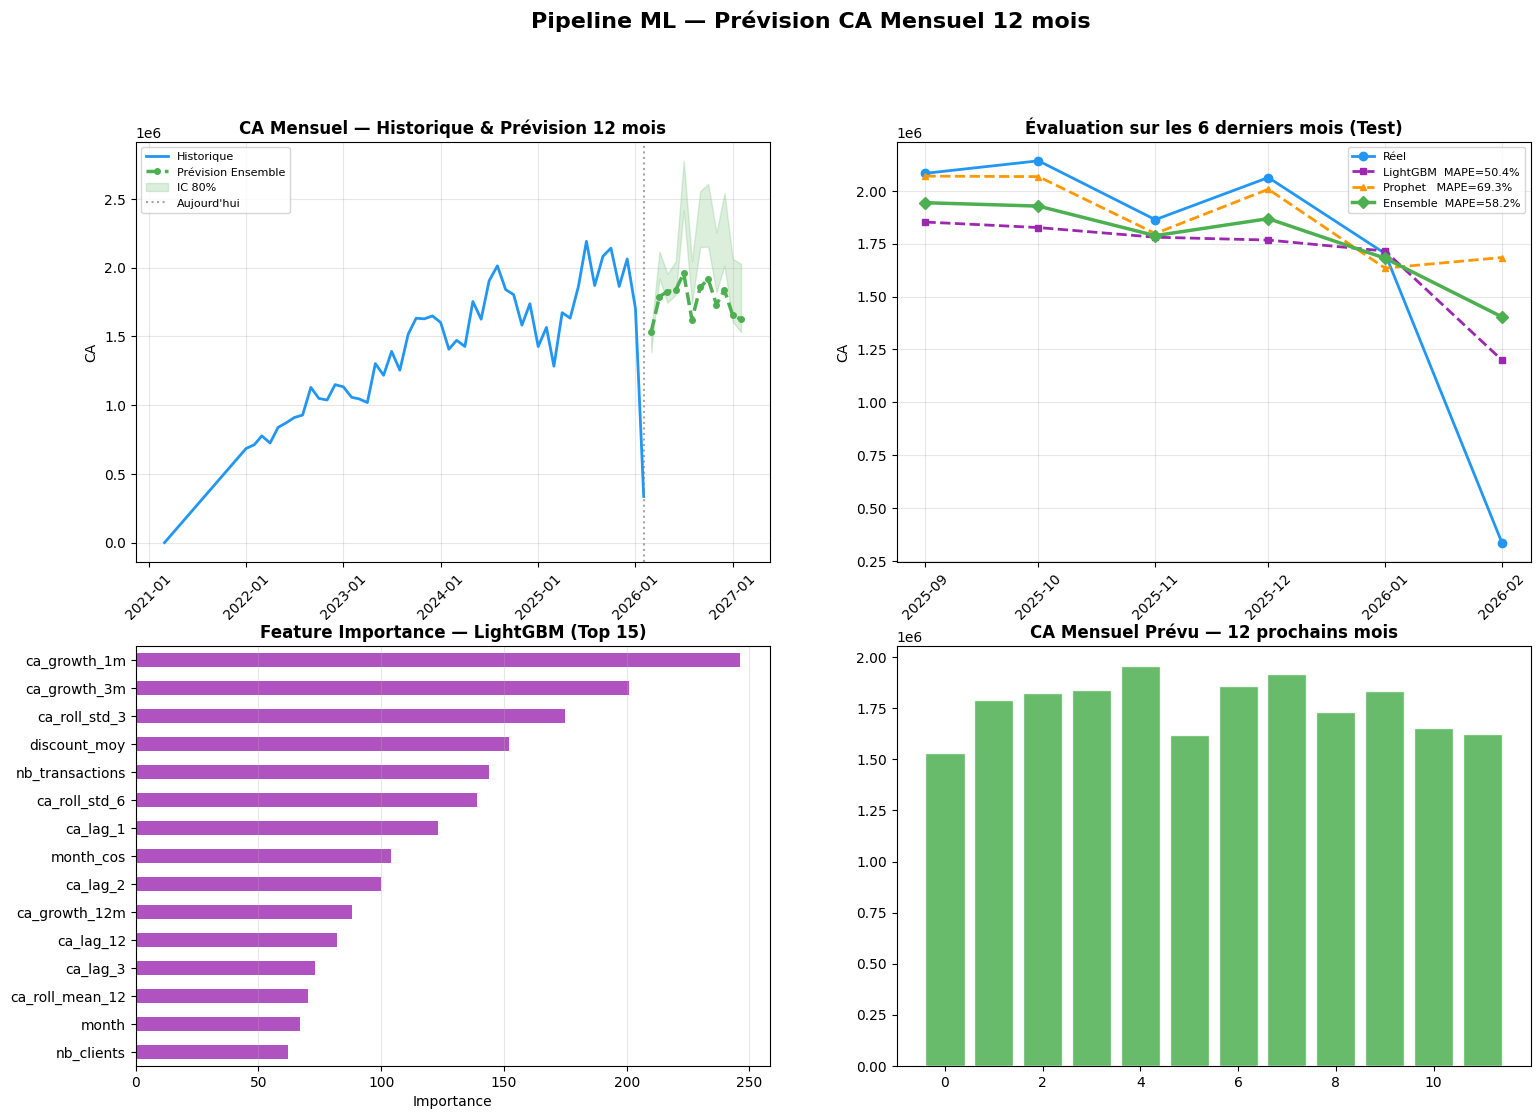

In [15]:
C_HIST = "#2196F3"; C_TEST = "#FF9800"; C_PRED = "#4CAF50"; C_LGB = "#9C27B0"

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Pipeline ML — Prévision CA Mensuel 12 mois", fontsize=16, fontweight="bold", y=0.99)

# 1. Historique + Prévision
ax = axes[0, 0]
ax.set_title("CA Mensuel — Historique & Prévision 12 mois", fontweight="bold")
ax.plot(df_monthly["ds"], df_monthly["ca_total"], color=C_HIST, lw=2, label="Historique")
ax.plot(forecast_final["ds"], forecast_final["yhat_ensemble"],
        color=C_PRED, lw=2.5, ls="--", marker="o", ms=4, label="Prévision Ensemble")
ax.fill_between(forecast_final["ds"], forecast_final["yhat_lower"],
                forecast_final["yhat_upper"], alpha=0.2, color=C_PRED, label="IC 80%")
ax.axvline(df_monthly["ds"].max(), color="gray", ls=":", alpha=0.7, label="Aujourd'hui")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylabel("CA")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)

# 2. Évaluation test
ax = axes[0, 1]
ax.set_title("Évaluation sur les 6 derniers mois (Test)", fontweight="bold")
ax.plot(test["ds"].values, y_test.values, color=C_HIST, lw=2, marker="o", ms=6, label="Réel")
ax.plot(test["ds"].values, pred_lgb_test,      color=C_LGB,  lw=2, ls="--", marker="s", ms=5,
        label=f"LightGBM  MAPE={mape_lgb:.1%}")
ax.plot(test["ds"].values, pred_prophet_test,  color=C_TEST, lw=2, ls="--", marker="^", ms=5,
        label=f"Prophet   MAPE={mape_prophet:.1%}")
ax.plot(test["ds"].values, pred_ensemble_test, color=C_PRED, lw=2.5, marker="D", ms=6,
        label=f"Ensemble  MAPE={mape_ensemble:.1%}")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylabel("CA")
ax.tick_params(axis="x", rotation=45)

# 3. Feature Importance
ax = axes[1, 0]
ax.set_title("Feature Importance — LightGBM (Top 15)", fontweight="bold")
feat_imp = pd.Series(model_lgb.feature_importances_, index=FEATURE_COLS).sort_values().tail(15)
feat_imp.plot(kind="barh", ax=ax, color=C_LGB, alpha=0.8)
ax.set_xlabel("Importance"); ax.grid(alpha=0.3, axis="x")

# 4. Barres prévision 12 mois
ax = axes[1, 1]
ax.set_title("CA Mensuel Prévu — 12 prochains mois", fontweight="bold")
x_labels = forecast_final["ds"].dt.strftime("%Y-%m")
bars = ax.bar(range(len(forecast_final)), forecast_final["yhat_ensemble"],
              color=C_PRED, alpha=0.85, edgecolor="white", zorder=3)
ax.errorbar(range(len(forecast_final)), forecast_final["yhat_ensemble"],
            yerr=[forecast_final["yhat_ensemble"] - forecast_final["yhat_lower"],
                  forecast_final["yhat_upper"]    - forecast_final["yhat_ensemble"]],
            fmt="none", color="gray", capsize=4, alpha=0.6)
for i, (bar, val) in enumerate(zip(bars, forecast_final["yhat_ensemble"])):
    ax.text(i, val * 1.02, f"{val/1000:.0f}k", ha="center", fontsize=7, fontweight="bold")
ax.axhline(df_monthly["ca_total"].tail(12).mean(), color="red", ls=":", alpha=0.7, label="Moy. 12m hist.")
ax.set_xticks(range(len(forecast_final))); ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("CA"); ax.legend(); ax.grid(alpha=0.3, axis="y", zorder=0)

plt.tight_layout()
plt.savefig("/app/forecast_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé : /app/forecast_results.png")


## 10. Sauvegarde → `gold.ml_predictions`

In [ ]:
client.command("""
    CREATE TABLE IF NOT EXISTS gold.ml_predictions (
        prediction_date  Date,
        target_month     Date,
        model_name       String,
        ca_predicted     Float64,
        ca_lower         Float64,
        ca_upper         Float64,
        mape_test        Float64,
        run_timestamp    DateTime DEFAULT now()
    )
    ENGINE = MergeTree()
    ORDER BY (prediction_date, target_month, model_name)
""")

from datetime import datetime
import pandas as pd

now = datetime.now()
rows_to_insert = [
    [
        now.date(),
        row["ds"].date(),
        "ensemble_lgb_prophet",
        float(row["yhat_ensemble"]),
        float(row["yhat_lower"]),
        float(row["yhat_upper"]),
        float(mape_ensemble),
    ]
    for _, row in forecast_final.iterrows()
]

col_names_insert = [
    "prediction_date", "target_month", "model_name",
    "ca_predicted", "ca_lower", "ca_upper", "mape_test"
]

client.insert("gold.ml_predictions", rows_to_insert, column_names=col_names_insert)
print(f"✅ {len(rows_to_insert)} prévisions insérées dans gold.ml_predictions")


## 11. Résumé Final

In [ ]:
print("=" * 60)
print("📊  RÉSUMÉ FINAL — PIPELINE ML PRÉVISION CA")
print("=" * 60)
print(f"  Train : {train['ds'].min().strftime('%Y-%m')} → {train['ds'].max().strftime('%Y-%m')}")
print(f"  Test  : {test['ds'].min().strftime('%Y-%m')}  → {test['ds'].max().strftime('%Y-%m')}")
print(f"  Horizon prévision : 12 mois")
print()
print(f"  {'Modèle':<22} {'MAPE':>8}  {'RMSE':>14}")
print(f"  {'-'*48}")
print(f"  {'LightGBM':<22} {mape_lgb:>8.2%}  {rmse_lgb:>14,.0f}")
print(f"  {'Prophet':<22} {mape_prophet:>8.2%}  {rmse_prophet:>14,.0f}")
print(f"  {'Ensemble (final)':<22} {mape_ensemble:>8.2%}  {rmse_ensemble:>14,.0f}  ← meilleur")
print()
print(f"  💰 CA prévu 12 mois  : {ca_annuel_prevu:>15,.0f}")
print(f"  📈 CA réel 12m hist  : {ca_annuel_hist:>15,.0f}")
print(f"  📊 Évolution prévue  : {delta_pct:>+14.1%}")
print("=" * 60)
print("✅ Pipeline terminé !")
print(f"   MLflow UI  → http://localhost:5000")
print(f"   Résultats  → gold.ml_predictions")
